# 51. N-Queens

## Problem Statement

The **n-queens puzzle** is the problem of placing $n$ queens on an $n \times n$ chessboard such that no two queens attack each other.

Given an integer $n$, return *all distinct solutions to the **n-queens puzzle***. You may return the answer in **any order**.

Each solution contains a distinct board configuration of the n-queens' placement, where `'Q'` and `'.'` indicate a queen and an empty space, respectively.

---

### Examples

#### Example 1
* **Input:** `n = 4`
* **Output:** `[[".Q..","...Q","Q...","..Q."],["..Q.","Q...","...Q",".Q.."]]`
* **Explanation:** There exist two distinct solutions to the 4-queens puzzle.

#### Example 2
* **Input:** `n = 1`
* **Output:** `[["Q"]]`

---

### Constraints
* $1 \le n \le 9$

---

## Optimal Solution (Backtracking with $\mathcal{O}(1)$ Constraint Checks)

### Intuition & Approach
Since queens attack horizontally, vertically, and diagonally, placing $n$ non-attacking queens on an $n \times n$ board means **exactly one queen must exist per row and per column**.

We can build solutions row by row using **Backtracking**:
1. Place a queen in row $r$ at column $c$.
2. Check if column $c$, main diagonal ($r - c$), or anti-diagonal ($r + c$) is already occupied by a previously placed queen.
3. Instead of scanning the board to check validity in $\mathcal{O}(n)$ time, maintain three sets/hash sets to track occupied lines in $\mathcal{O}(1)$ time:
   * `cols`: Track occupied columns ($c$).
   * `diag1` (Main Diagonals): Track occupied $r - c$ values.
   * `diag2` (Anti-Diagonals): Track occupied $r + c$ values.
4. Advance to row $r + 1$. When row $r == n$, convert the current queen positions to the string board representation and save the solution.

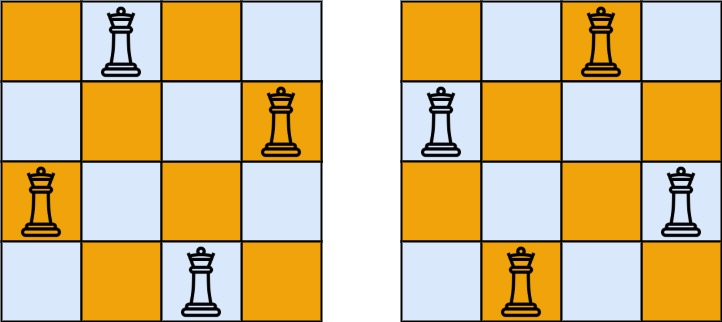

In [11]:
class Solution:
    def solveNQueens(self, n: int) -> list[list[str]]:
        res = []
        board = [["."] * n for _ in range(n)]
        
        def isSafe(row,col):
            # check column
            for i in range(row):
                if board[i][col] == "Q":
                    return False
        
            # Check upper-left diagonal
            i,j=row-1,col-1
            while i>=0 and j>=0:
                if board[i][j]=="Q":
                    return False
                i-=1
                j-=1
            
            # Check upper-right diagonal    
            i,j=row-1,col+1
            while i>=0 and j<n:
                if board[i][j]=="Q":
                    return False
                i-=1
                j+=1
            return True

        def backtrack(row):
            if row == n:
                temp = ["".join(r) for r in board]
                res.append(temp)
                return
                        
            for col in range(n):
                if isSafe(row,col):
                    board[row][col] = "Q"
                    backtrack(row+1)
                    board[row][col] = "."       
        
        backtrack(0)
        return res

In [12]:
s= Solution()
result = s.solveNQueens(4)
print(result)  # Output: [[".Q..","...Q","Q...","..Q."],["..Q.","Q...","...Q",".Q.."]]

[['.Q..', '...Q', 'Q...', '..Q.'], ['..Q.', 'Q...', '...Q', '.Q..']]


In [13]:
s= Solution()
result = s.solveNQueens(1)
print(result)  # Output: [["Q"]]

[['Q']]


### Complexity
* **Time Complexity:** $\mathcal{O}(n!)$ — There are $n$ choices for the first row, at most $n-1$ for the second row, $n-2$ for the third, etc. Constraint checks run in $\mathcal{O}(1)$ time.
* **Space Complexity:** $\mathcal{O}(n)$ — Recursion stack depth is $n$, and hash sets store at most $n$ items.